<a href="https://colab.research.google.com/github/zaidlameer/DeetectorPrototype/blob/main/audioRnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prompt: mount drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.1 MB/s eta 0:00:00


In [12]:
DATA_PATH = "/content/drive/MyDrive/audio_dataset_custom"

In [14]:
import os

print(os.listdir(DATA_PATH))

['real', 'fake']


Extracting Features: 100%|██████████| 4087/4087 [32:31<00:00,  2.09it/s]


Training set: (2615, 100, 13), (2615,)
Validation set: (654, 100, 13), (654,)
Test set: (818, 100, 13), (818,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          72,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 124,258 (485.38 KB)

 Trainable params: 124,258 (485.38 KB)

 Non-trainable params: 0 (0.00 B)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - accuracy: 0.5444 - loss: 0.6807 - val_accuracy: 0.6835 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step - accuracy: 0.7230 - loss: 0.5516 - val_accuracy: 0.7951 - val_loss: 0.4349 - learning_rate: 0.0010
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 223ms/step - accuracy: 0.7702 - loss: 0.4899 - val_accuracy: 0.8196 - val_loss: 0.3929 - learning_rate: 0.0010
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - accuracy: 0.7970 - loss: 0.4265 - val_accuracy: 0.8563 - val_loss: 0.3405 - learning_rate: 0.0010
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step - accuracy: 0.8401 - loss: 0.3733 - val_accuracy: 0.8364 - val_loss: 0.3690 - learning_rate: 0.0010
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 223ms/step - accuracy: 0.8568 - loss: 0.3532 - val_accuracy: 0.8624 - val_loss: 0.3003 - learning_rate: 0.0010
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 240ms/step - accuracy: 0.8753 - loss: 0.

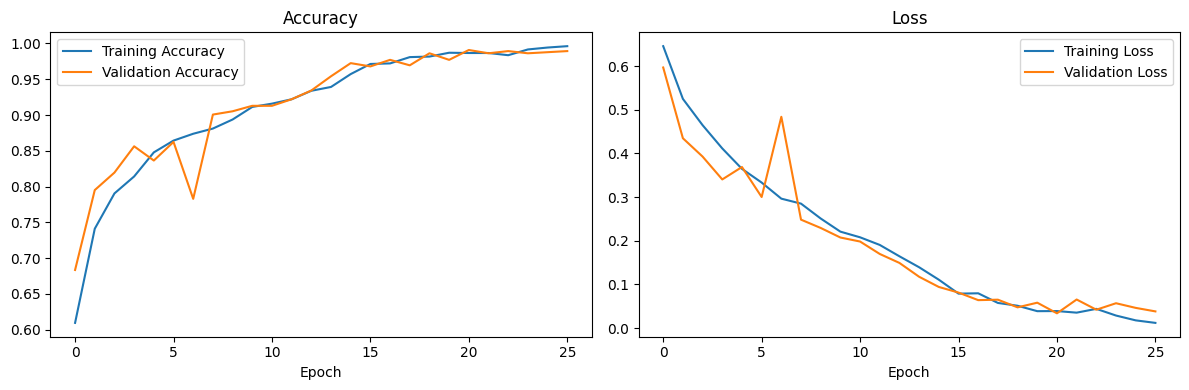

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


Sample 0: True: real, Predicted: real
Sample 1: True: fake, Predicted: fake
Sample 2: True: fake, Predicted: fake
Sample 3: True: real, Predicted: real
Sample 4: True: real, Predicted: real
Sample 5: True: fake, Predicted: fake
Sample 6: True: real, Predicted: real
Sample 7: True: real, Predicted: real
Sample 8: True: fake, Predicted: real
Sample 9: True: real, Predicted: real


In [16]:
import pandas as pd
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
from tqdm import tqdm
from tqdm.keras import TqdmCallback

warnings.filterwarnings('ignore')

# Set seed for reproducibility
SEED = 456
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = "/content/drive/MyDrive/audio_dataset_custom"

# Feature extraction
def extract_features(file_path, n_mfcc=13, n_fft=2048, hop_length=512, max_len=100):
    try:
        audio, sr = librosa.load(file_path, sr=None)
        if len(audio) > sr * 10:
            audio = audio[:sr * 10]
        else:
            padding = sr * 10 - len(audio)
            audio = np.pad(audio, (0, padding), 'constant')
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        mfccs = (mfccs - np.mean(mfccs)) / np.std(mfccs)
        mfccs = mfccs.T
        if len(mfccs) > max_len:
            mfccs = mfccs[:max_len]
        else:
            mfccs = np.pad(mfccs, ((0, max_len - len(mfccs)), (0, 0)), 'constant')
        return mfccs
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Load dataset
def load_data_from_files():
    file_paths = []
    labels = []
    for class_name in os.listdir(DATA_PATH):
        class_dir = os.path.join(DATA_PATH, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if file_name.endswith(('.wav', '.flac')):
                    file_paths.append(os.path.join(class_dir, file_name))
                    labels.append(class_name)
    return file_paths, labels

file_paths, labels = load_data_from_files()

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# tqdm for feature extraction
features = []
valid_indices = []

for i in tqdm(range(len(file_paths)), desc="Extracting Features"):
    feature = extract_features(file_paths[i])
    if feature is not None:
        features.append(feature)
        valid_indices.append(i)

# Keep only valid labels
valid_labels = [encoded_labels[i] for i in valid_indices]

# Convert to numpy arrays
X = np.array(features)
y = np.array(valid_labels)

# Train/val/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

# Build RNN model
def create_rnn_model(input_shape, num_classes):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = len(np.unique(y))

model = create_rnn_model(input_shape, num_classes)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# Train with tqdm callback
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        TqdmCallback(verbose=1),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

predicted_labels = label_encoder.inverse_transform(predicted_classes)
true_labels = label_encoder.inverse_transform(y_test)

for i in range(min(10, len(predicted_labels))):
    print(f"Sample {i}: True: {true_labels[i]}, Predicted: {predicted_labels[i]}")

# Save model
model.save('audio_rnn_model.h5')
